1. Convert the prompt “an underwater fantasy city” into token IDs and then raw tokens. Name the list of token IDs token_ids2.

In [ ]:
!git clone https://github.com/kuprel/min-dalle

fatal: destination path 'min-dalle' already exists and is not an empty directory.


In [ ]:
import os

folder="files/DALLE"
if not os.path.exists(folder):    #If the folder files/DALLE does not exist, create the folder
    os.makedirs(folder)

In [ ]:
import requests

url='https://huggingface.co/kuprel/min-dalle/resolve/main/'
vocab_path=folder+"/vocab.json"
merges_path=folder+"/merges.txt"

if not (os.path.exists(vocab_path)
    and os.path.exists(merges_path)):    #If either vocab.json or merges.txt are not present, start downloading
    print("downloading tokenizer parameters")

    vocab = requests.get(url + 'vocab.json')
    merges = requests.get(url + 'merges.txt')
    with open(vocab_path, 'wb') as f:
        f.write(vocab.content)
    with open(merges_path, 'wb') as f:    #Downloads the two files and saves them
        f.write(merges.content)
else:    #Skips if the two files have already been downloaded
    print("tokenizer parameters have already been downloaded")

tokenizer parameters have already been downloaded


In [ ]:
!pip install emoji

In [ ]:
import sys
sys.path.append("min-dalle")    #Adds the min-dalle folder to Python’s search path

import json
from min_dalle.text_tokenizer import TextTokenizer    #Imports the TextTokenizer class from the min-DALL-E GitHub repository

print("intializing TextTokenizer")
with open(vocab_path, 'r', encoding='utf8') as f:
    vocab = json.load(f)
with open(merges_path, 'r', encoding='utf8') as f:
    merges = f.read().split("\n")[1:-1]    #Loads the tokenizer files
tokenizer = TextTokenizer(vocab, merges)    #Initializes the tokenizer

intializing TextTokenizer


In [ ]:
print({k:v for k,v in vocab.items() if v<10})

{'<s>': 0, '<pad>': 1, '</s>': 2, '<unk>': 3, '<mask>': 4, '"': 5, '$': 6, '%': 7, '&': 8, "'": 9}


In [ ]:
text2 = "an underwater fantasy city"#aici-----------------------------------------------------
token_ids2 = tokenizer.tokenize(text2)    #Tokenizes text to get token IDs
print("Token IDs:", token_ids2)

idx2token = {v: k for k, v in vocab.items()}    #Reverses the vocab dictionary to map IDs to tokens

raw_tokens2 = [idx2token.get(i, "<unk>") for i in token_ids2]    #Maps token IDs to raw tokens
print("Raw Tokens:", raw_tokens2)

Token IDs: [0, 101, 10892, 3091, 645, 2]
Raw Tokens: ['<s>', 'Ġan', 'Ġunderwater', 'Ġfantasy', 'Ġcity', '</s>']


2. Use the list of token IDs token_ids2 that was created in Exercise 1 to create a PyTorch tensor text_tokens2. Make sure that text_tokens2 has a shape of  (2,64) , representing the padded token IDs for the unconditional prompt and the text prompt “an underwater fantasy city”, respectively. Print out the values of text_tokens2.

In [ ]:
import numpy, torch

device="cuda" if torch.cuda.is_available() else "cpu"

text_tokens2 = numpy.ones((2, 64), dtype=numpy.int32)    #Initializes a NumPy array filled with the <pad> token (index 1)
text_tokens2[0, :2] = [token_ids2[0], token_ids2[-1]]    #Creates the unconditional prompt, with just two tokens <s> and </s>
text_tokens2[1, :len(token_ids2)] = token_ids2    #Creates the padded conditional prompt
text_tokens2 = torch.tensor(text_tokens2,
    dtype=torch.long, device=device)    #Converts the input to a PyTorch long tensor
print(text_tokens2)

tensor([[    0,     2,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1],
        [    0,   101, 10892,  3091,   645,     2,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1

3. Use the BART text encoder to generate text embeddings for the PyTorch tensor text_tokens2 that was created in Exercise 2. Name the text embeddings encoder_state2, and print out its shape.

In [ ]:
encoder_path=folder+"/encoder.pt"

if not os.path.exists(encoder_path):    #If the weights are not available locally, downloads them from Hugging Face
    print("downloading encoder parameters")
    ws = requests.get(url + 'encoder.pt')
    with open(encoder_path, 'wb') as f:
        f.write(ws.content)
else:    #Otherwise, skips downloading
    print("encoder parameters have already been downloaded")

encoder parameters have already been downloaded


In [ ]:
from min_dalle.models import DalleBartEncoder

torch.manual_seed(42)    #Fixes the random state so results are reproducible
dtype = "float16"
print("initializing DalleBartEncoder")
encoder = DalleBartEncoder(    #Instantiates the DalleBartEncoder class to create the BART encoder
    attention_head_count = 32,
    embed_count = 2048,    #Text embeddings have a dimension of 2048
    glu_embed_count = 4096,
    text_token_count = 64,    #Text prompts have 64 tokens
    text_vocab_count = 50272,
    layer_count = 24,
    device=device
).to(getattr(torch, dtype)).eval()
params = torch.load(encoder_path)
encoder.load_state_dict(params, strict=False)    #Loads the pretrained weights
del params
encoder = encoder.to(device)

initializing DalleBartEncoder


In [ ]:
with torch.amp.autocast("cuda", dtype=getattr(torch, dtype)):
    encoder_state2 = encoder.forward(text_tokens2)
torch.cuda.empty_cache()
print("Shape of the text embeddings:", encoder_state2.shape)

Shape of the text embeddings: torch.Size([2, 64, 2048])


4. Create three tensors, attention_mask2, attention_state2, and image_tokens2, to represent the attention mask, attention state cache, and image tokens for the text prompt “an underwater fantasy city”.

In [ ]:
torch.save(text_tokens2, "files/DALLE/text_tokens.pt")
torch.save(encoder_state2, "files/DALLE/encoder_state.pt")

In [ ]:
import os

folder="files/DALLE"

import sys
sys.path.append("min-dalle")

import numpy, torch

device="cuda" if torch.cuda.is_available() else "cpu"

dtype = "float16"

text_tokens=torch.load("files/DALLE/text_tokens.pt")
encoder_state=torch.load("files/DALLE/encoder_state.pt")

import requests

url='https://huggingface.co/kuprel/min-dalle/resolve/main/'

In [ ]:
decoder_path=folder+"/decoder.pt"

if not os.path.exists(decoder_path):    #Downloads the pretrained BART decoder weights if they are not saved locally
    print("downloading decoder parameters")
    weights = requests.get(url + 'decoder.pt')
    with open(decoder_path, 'wb') as f:
        f.write(weights.content)
else:
    print("decoder parameters have already been downloaded")

decoder parameters have already been downloaded


In [ ]:
from min_dalle.models import DalleBartDecoder

print("initializing DalleBartDecoder")
decoder = DalleBartDecoder(    #Creates a BART decoder
    image_vocab_count = 16415,
    attention_head_count = 32,
    embed_count = 2048,
    glu_embed_count = 4096,
    layer_count = 24,
    device=device
).to(getattr(torch, dtype)).eval()
params = torch.load(decoder_path)    #Loads the trained weights
decoder.load_state_dict(params, strict=False)
del params
decoder = decoder.to(device)

initializing DalleBartDecoder


In [ ]:
attention_mask2=text_tokens2.not_equal(1)[:, None, None, :]    #Creates an attention mask
attention_state2=torch.zeros(size=(24,4,256,2048),    #Creates an attention_state cache
    device=device)
image_tokens2=torch.full((1, 256 + 1),    #Creates a sequence of 257 image tokens, filled with a special placeholder token
    2 ** 14 - 1,dtype=torch.long,device=device)

5. Predict image tokens iteratively for the prompt “an underwater fantasy city”. Save all intermediate image tokens in a list imgtokens2 as we did earlier.

In [ ]:
token_indices2=torch.arange(256,device=device)
temperature=0.5    #Sets the temperature parameter to 0.5
top_k=128    #Sets the top-K sampling parameter to 128
supercondition_factor=4    #Sets the supercondition factor to 4
settings = torch.tensor(
    [temperature, top_k, supercondition_factor],
    dtype=torch.float32,device=device)

In [ ]:
from copy import deepcopy

imgtokens2=[]    #Creates a list imgtokens to store intermediate steps
for i in range(256):    #Iterates 256 steps
    torch.cuda.empty_cache()
    with torch.amp.autocast("cuda",dtype=getattr(torch, dtype)):
        image_tokens2[:, i + 1], attention_state = decoder.sample_tokens(    #Predicts the next token using previous tokens and the text embeddings
            settings=settings,
            attention_mask=attention_mask2,
            encoder_state=encoder_state,
            attention_state=attention_state,
            prev_tokens=image_tokens2[:, [i]],
            token_index=token_indices2[[i]])
        imgtokens2.append(deepcopy(image_tokens2))

6. Display the generated image for the prompt “an underwater fantasy city”.

In [ ]:
detokenizer_path=folder+"/detoker.pt"
if not os.path.exists(detokenizer_path):    #Downloads the pretrained weights for the VQGAN detokenizer
    print("downloading detokenizer parameters")
    ws = requests.get(url + 'detoker.pt')
    with open(detokenizer_path, 'wb') as f:
        f.write(ws.content)
else:
    print("detokenizer parameters have already been downloaded")

detokenizer parameters have already been downloaded


In [ ]:
from min_dalle.models import VQGanDetokenizer

print("initializing VQGanDetokenizer")
detokenizer = VQGanDetokenizer().eval()    #Initializes the VQGAN detokenizer and set it to evaluation mode
params = torch.load(detokenizer_path)
detokenizer.load_state_dict(params)    #Loads the pretrained weights
del params
detokenizer = detokenizer.to(device)

initializing VQGanDetokenizer


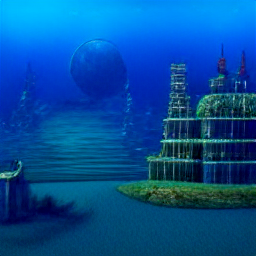

In [ ]:
from PIL import Image

torch.cuda.empty_cache()
image2 = detokenizer.forward(True,
        image_tokens2[:, 1:])    #Decodes image tokens to an image tensor (skip the BOS token)
image2 = image2.to(torch.uint8).to('cpu').numpy()    #Converts the image tensor to NumPy arrays
image2 = Image.fromarray(image2)    #Converts NumPy arrays to an actual image using the PIL library
image2.save("files/minDALLE.png")
image2

7. Display the  32 nd,  64 th, . . ., and  256 th images in the list imgtokens2 that was created in Exercise 5 in a  2×4  grid.

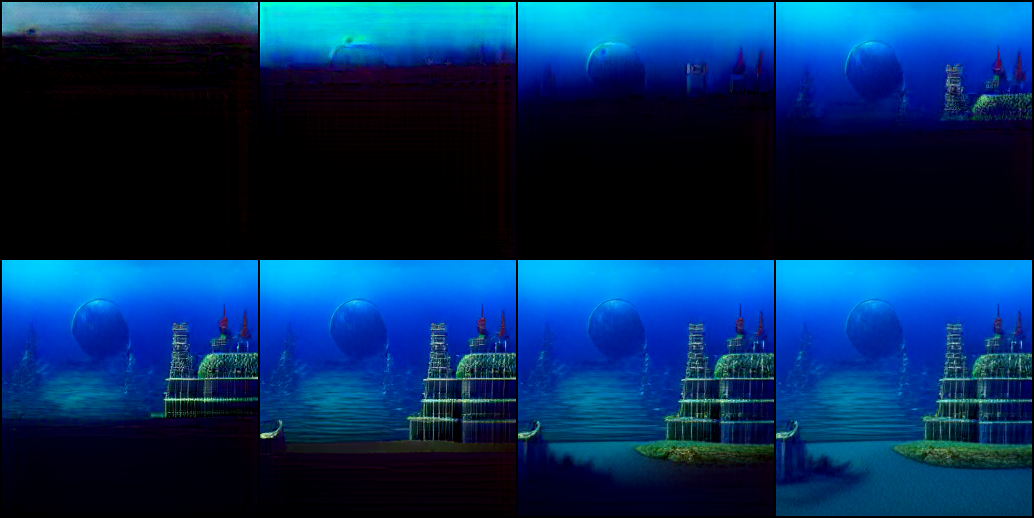

In [ ]:
from torchvision.utils import make_grid
from torchvision.transforms import ToPILImage

imgs2=[]
for i in range(8):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True,
      imgtokens2[32*(i+1)-1][:, 1:])    #Selects images at steps 32, 64, 96, 128, 160, 192, 224, and 256.
    imgs2.append(images.permute(2,0,1).to(torch.uint8))
grid=make_grid(imgs2,nrow=4)    #Places the 8 images in a 2 x 4 grid
img=ToPILImage()(grid)
img.save("files/minDALLEsteps.png")
img

8. Generate an animation using the  256  images in the list imgtokens2 that was created in Exercise 5.

In [ ]:
vids=[]    #Creates a list vids to store all intermediate images
for i in range(len(imgtokens2)):
    torch.cuda.empty_cache()
    images = detokenizer.forward(True,
      imgtokens2[i][:, 1:])    #Generates an image in each of the 256 intermediate steps
    image = images.to(torch.uint8).to('cpu').numpy()
    vids.append(Image.fromarray(image))

import imageio
imageio.mimsave("files/minDALLE.gif",    #Uses the imageio library to create an animation
        vids,fps=30)